# Comparative Exploratory Data Analysis (EDA): Round 1 vs. Round 2
This notebook contains the complete comparative analysis of the datasets from **Round 1** and **Round 2** of the ANRF-AISEHack-2.0 competition.

### Goal of this Analysis
The objective is to understand the differences, overlaps, and similarities between the Round 1 and Round 2 datasets. This helps in:
1. Understanding if the chemical space has shifted or expanded.
2. Checking for data overlap or leakage.
3. Identifying changes in target value distributions and target types.
4. Analyzing the polymer representation (SMILES) and checking validity and chemical characteristics.
5. Evaluating how the datasets align with the background `PI1M` dataset.

### Table of Contents
1. [Setup and Data Loading](#1.-Setup-and-Data-Loading)
2. [Dataset Sizes and Split Comparison](#2.-Dataset-Sizes-and-Split-Comparison)
3. [Target Type Analysis](#3.-Target-Type-Analysis)
4. [SMILES Overlap and Leakage Analysis](#4.-SMILES-Overlap-and-Leakage-Analysis)
5. [RDKit Chemical Descriptors and Properties](#5.-RDKit-Chemical-Descriptors-and-Properties)
6. [Target Value Distribution Comparison](#6.-Target-Value-Distribution-Comparison)
7. [Chemical Space Visualization (Morgan Fingerprints & PCA)](#7.-Chemical-Space-Visualization-(Morgan-Fingerprints-&-PCA))
8. [Summary of Findings](#8.-Summary-of-Findings)


In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit imports
from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys, rdFingerprintGenerator
from rdkit import RDLogger

# SciPy and Scikit-Learn
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

# Matplotlib settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Setup and Data Loading
Let's define the paths and load the following datasets:
- **Round 1 Train**: `Round1_archive/dataset/train.csv`
- **Round 1 Test**: `Round1_archive/dataset/test.csv`
- **Round 2 Train**: `dataset/train.csv`
- **Round 2 Test**: `dataset/test.csv`
- **PI1M Dataset**: `dataset/PI1M.csv` (contains ~1M polymer SMILES)


In [2]:
# Define paths (relative to notebook directory)
r1_train_path = os.path.join('..', 'Round1_archive', 'dataset', 'train.csv')
r1_test_path = os.path.join('..', 'Round1_archive', 'dataset', 'test.csv')
r2_train_path = os.path.join('..', 'dataset', 'train.csv')
r2_test_path = os.path.join('..', 'dataset', 'test.csv')
pi1m_path = os.path.join('..', 'dataset', 'PI1M.csv')

# Load datasets
r1_train = pd.read_csv(r1_train_path)
r1_test = pd.read_csv(r1_test_path)
r2_train = pd.read_csv(r2_train_path)
r2_test = pd.read_csv(r2_test_path)

# Load PI1M dataset (only need the SMILES column, read a subset or full depending on performance, full is ~1M)
print("Loading PI1M dataset...")
pi1m = pd.read_csv(pi1m_path)
print("PI1M loaded.")

# Print shapes
print(f"Round 1 Train shape: {r1_train.shape}")
print(f"Round 1 Test shape: {r1_test.shape}")
print(f"Round 2 Train shape: {r2_train.shape}")
print(f"Round 2 Test shape: {r2_test.shape}")
print(f"PI1M shape: {pi1m.shape}")


Loading PI1M dataset...


PI1M loaded.
Round 1 Train shape: (6171, 3)
Round 1 Test shape: (4115, 3)
Round 2 Train shape: (7409, 3)
Round 2 Test shape: (4940, 3)
PI1M shape: (995799, 1)


## 2. Dataset Sizes and Split Comparison
Let's visualize and compare the total number of records across the splits of Round 1 and Round 2.


Total Round 1 Records: 10286
Total Round 2 Records: 12349
Increase in dataset size: 2063 records (+20.06%)


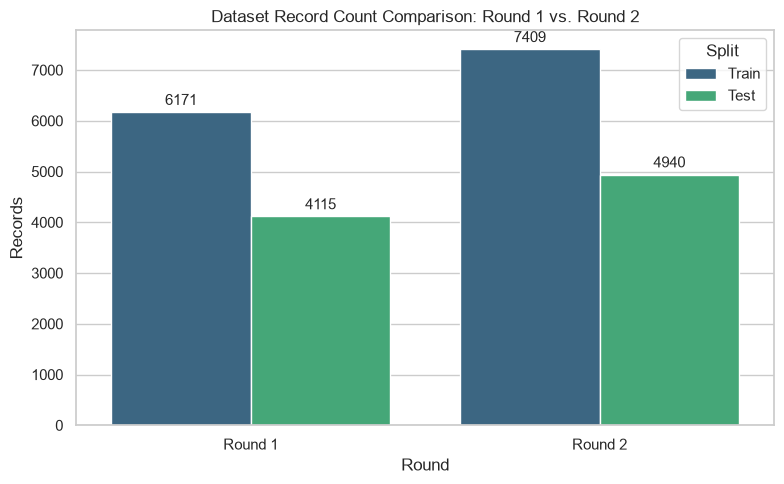

Split,Test,Train,Total,Train Ratio %
Round,,,,
Round 1,4115,6171,10286,59.99
Round 2,4940,7409,12349,60.00


In [3]:
# Build size dataframe
sizes = pd.DataFrame({
    'Round': ['Round 1', 'Round 1', 'Round 2', 'Round 2'],
    'Split': ['Train', 'Test', 'Train', 'Test'],
    'Records': [len(r1_train), len(r1_test), len(r2_train), len(r2_test)]
})

# Add total
total_r1 = len(r1_train) + len(r1_test)
total_r2 = len(r2_train) + len(r2_test)
print(f"Total Round 1 Records: {total_r1}")
print(f"Total Round 2 Records: {total_r2}")
print(f"Increase in dataset size: {total_r2 - total_r1} records (+{(total_r2 - total_r1)/total_r1*100:.2f}%)")

# Plot sizes
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=sizes, x='Round', y='Records', hue='Split', palette='viridis')
plt.title('Dataset Record Count Comparison: Round 1 vs. Round 2')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/dataset_sizes.png', dpi=300)
plt.show()

# Display table
sizes_pivot = sizes.pivot(index='Round', columns='Split', values='Records')
sizes_pivot['Total'] = sizes_pivot['Train'] + sizes_pivot['Test']
sizes_pivot['Train Ratio %'] = (sizes_pivot['Train'] / sizes_pivot['Total'] * 100).round(2)
sizes_pivot


## 3. Target Type Analysis
Let's analyze the distribution of `target_type` in the datasets. 
This tells us:
- What physical properties are being modeled (e.g., `tg` for glass transition temperature, `egc`, etc.).
- Whether the ratio of target types is consistent between training and testing, and between Round 1 and Round 2.


Round 1 Test target types: ['tg', 'egc']
Round 1 Train target types: ['tg', 'egc']
Round 2 Test target types: ['egc', 'tg', 'egb', 'eps', 'ei', 'eea', 'nc']
Round 2 Train target types: ['tg', 'egc', 'eps', 'eea', 'egb', 'ei', 'nc']


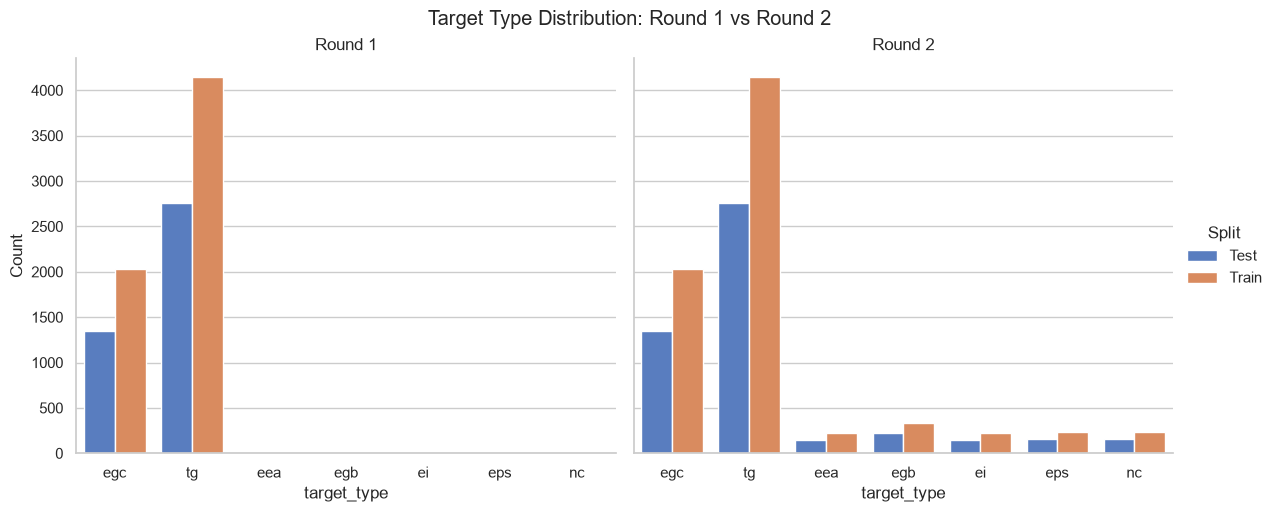

--- Counts by Target Type ---


target_type    eea  egb   egc   ei  eps   nc    tg
Round   Split                                     
Round 1 Test     0    0  1352    0    0    0  2763
        Train    0    0  2028    0    0    0  4143
Round 2 Test   147  224  1352  148  153  153  2763
        Train  221  337  2028  222  229  229  4143


--- Percentages by Target Type (%) ---


target_type     eea   egb    egc   ei   eps    nc     tg
Round   Split                                           
Round 1 Test   0.00  0.00  32.86  0.0  0.00  0.00  67.14
        Train  0.00  0.00  32.86  0.0  0.00  0.00  67.14
Round 2 Test   2.98  4.53  27.37  3.0  3.10  3.10  55.93
        Train  2.98  4.55  27.37  3.0  3.09  3.09  55.92

In [4]:
# Combine into one DataFrame for target types analysis
r1_train['Round'] = 'Round 1'
r1_train['Split'] = 'Train'
r1_test['Round'] = 'Round 1'
r1_test['Split'] = 'Test'
r2_train['Round'] = 'Round 2'
r2_train['Split'] = 'Train'
r2_test['Round'] = 'Round 2'
r2_test['Split'] = 'Test'

# Combine
all_df = pd.concat([
    r1_train[['smiles', 'target_type', 'Round', 'Split']],
    r1_test[['smiles', 'target_type', 'Round', 'Split']],
    r2_train[['smiles', 'target_type', 'Round', 'Split']],
    r2_test[['smiles', 'target_type', 'Round', 'Split']]
], ignore_index=True)

# Group and count
tt_counts = all_df.groupby(['Round', 'Split', 'target_type']).size().reset_index(name='Count')

# Print target types present in each
for name, group in all_df.groupby(['Round', 'Split']):
    print(f"{name[0]} {name[1]} target types: {group['target_type'].unique().tolist()}")

# Plot target type distributions
g = sns.catplot(
    data=tt_counts, kind="bar",
    x="target_type", y="Count", hue="Split", col="Round",
    palette="muted", height=5, aspect=1.2
)
g.set_titles("{col_name}")
g.fig.suptitle("Target Type Distribution: Round 1 vs Round 2", y=1.02)
plt.savefig('plots/target_type_distribution.png', dpi=300)
plt.show()

# Let's display the pivot table with percentages
tt_pivot = all_df.groupby(['Round', 'Split', 'target_type']).size().unstack(fill_value=0)
# Add percentage row-wise
tt_pct = tt_pivot.div(tt_pivot.sum(axis=1), axis=0) * 100
print("--- Counts by Target Type ---")
display(tt_pivot)
print("\n--- Percentages by Target Type (%) ---")
display(tt_pct.round(2))


## 4. SMILES Overlap and Leakage Analysis
Here we analyze the SMILES strings:
1. **Uniqueness**: How many unique SMILES strings are in each split?
2. **Duplicate SMILES**: Do we have duplicates inside the same split? If yes, are the targets consistent?
3. **Train-Test Overlap (Data Leakage)**: Is the test set SMILES present in the training set?
   - R1 Train vs. R1 Test
   - R2 Train vs. R2 Test
4. **Cross-Round Overlap**:
   - How much of R2 Train is from R1 Train?
   - Is R1 Test present in R2 Train? (Common if datasets were re-split).
   - Is R2 Test present in R1 Train? (Very critical: if R2 Test was in R1 Train, then models trained on R1 Train will have leaked R2 Test).
5. **PI1M Coverage**: What fraction of our R1 and R2 SMILES are found in the 1M background dataset?


In [5]:
# Extract SMILES sets
s1_tr = set(r1_train['smiles'].dropna())
s1_te = set(r1_test['smiles'].dropna())
s2_tr = set(r2_train['smiles'].dropna())
s2_te = set(r2_test['smiles'].dropna())
spi1m = set(pi1m['SMILES'].dropna())

print("--- Unique SMILES Counts ---")
print(f"Round 1 Train: {len(s1_tr)} unique SMILES (out of {len(r1_train)} rows)")
print(f"Round 1 Test:  {len(s1_te)} unique SMILES (out of {len(r1_test)} rows)")
print(f"Round 2 Train: {len(s2_tr)} unique SMILES (out of {len(r2_train)} rows)")
print(f"Round 2 Test:  {len(s2_te)} unique SMILES (out of {len(r2_test)} rows)")

print("\n--- Train-Test Leakage Analysis (Same Round) ---")
leakage_r1 = s1_tr.intersection(s1_te)
leakage_r2 = s2_tr.intersection(s2_te)
print(f"Round 1 Train vs Test overlap: {len(leakage_r1)} SMILES")
print(f"Round 2 Train vs Test overlap: {len(leakage_r2)} SMILES")

print("\n--- Cross-Round Overlap Analysis ---")
print(f"R1 Train vs R2 Train overlap (How much R1 Train is in R2 Train): {len(s1_tr.intersection(s2_tr))} / {len(s1_tr)} ({len(s1_tr.intersection(s2_tr))/len(s1_tr)*100:.2f}%)")
print(f"R1 Test vs R2 Train overlap (Did R1 Test move to R2 Train?): {len(s1_te.intersection(s2_tr))} / {len(s1_te)} ({len(s1_te.intersection(s2_tr))/len(s1_te)*100:.2f}%)")
print(f"R2 Test vs R1 Train overlap (Potential leakage of R2 Test in R1 Train!): {len(s2_te.intersection(s1_tr))} / {len(s2_te)} ({len(s2_te.intersection(s1_tr))/len(s2_te)*100:.2f}%)")
print(f"R2 Test vs R1 Test overlap: {len(s2_te.intersection(s1_te))} / {len(s2_te)} ({len(s2_te.intersection(s1_te))/len(s2_te)*100:.2f}%)")

print("\n--- Background PI1M Dataset Overlap ---")
print(f"R1 Train in PI1M: {len(s1_tr.intersection(spi1m))} / {len(s1_tr)} ({len(s1_tr.intersection(spi1m))/len(s1_tr)*100:.2f}%)")
print(f"R1 Test in PI1M:  {len(s1_te.intersection(spi1m))} / {len(s1_te)} ({len(s1_te.intersection(spi1m))/len(s1_te)*100:.2f}%)")
print(f"R2 Train in PI1M: {len(s2_tr.intersection(spi1m))} / {len(s2_tr)} ({len(s2_tr.intersection(spi1m))/len(s2_tr)*100:.2f}%)")
print(f"R2 Test in PI1M:  {len(s2_te.intersection(spi1m))} / {len(s2_te)} ({len(s2_te.intersection(spi1m))/len(s2_te)*100:.2f}%)")

print("\n--- Duplicate SMILES with Conflicting Target Values ---")
def check_duplicates_conflict(df, name):
    # Group by smiles and target_type
    dupes = df[df.duplicated(subset=['smiles', 'target_type'], keep=False)]
    if len(dupes) == 0:
        print(f"No duplicates in {name} by (smiles, target_type).")
        return
    
    # Calculate target range/std for duplicates
    stats_dupes = dupes.groupby(['smiles', 'target_type'])['target'].agg(['count', 'min', 'max', 'std']).reset_index()
    stats_dupes['diff'] = stats_dupes['max'] - stats_dupes['min']
    conflicting = stats_dupes[stats_dupes['diff'] > 1e-5]
    print(f"{name}: Found {len(stats_dupes)} groups of duplicate SMILES-target_type pairs.")
    print(f"  Total duplicate records: {len(dupes)}")
    print(f"  Conflicting groups (diff in target value > 0): {len(conflicting)}")
    if len(conflicting) > 0:
        print("  Top conflicting examples (sorted by target difference):")
        display(conflicting.sort_values(by='diff', ascending=False).head(5))

check_duplicates_conflict(r1_train, "Round 1 Train")
check_duplicates_conflict(r2_train, "Round 2 Train")


--- Unique SMILES Counts ---
Round 1 Train: 6158 unique SMILES (out of 6171 rows)
Round 1 Test:  4111 unique SMILES (out of 4115 rows)
Round 2 Train: 6565 unique SMILES (out of 7409 rows)
Round 2 Test:  4497 unique SMILES (out of 4940 rows)

--- Train-Test Leakage Analysis (Same Round) ---
Round 1 Train vs Test overlap: 5 SMILES
Round 2 Train vs Test overlap: 457 SMILES

--- Cross-Round Overlap Analysis ---
R1 Train vs R2 Train overlap (How much R1 Train is in R2 Train): 3761 / 6158 (61.08%)
R1 Test vs R2 Train overlap (Did R1 Test move to R2 Train?): 2475 / 4111 (60.20%)
R2 Test vs R1 Train overlap (Potential leakage of R2 Test in R1 Train!): 2502 / 4497 (55.64%)
R2 Test vs R1 Test overlap: 1696 / 4497 (37.71%)

--- Background PI1M Dataset Overlap ---
R1 Train in PI1M: 99 / 6158 (1.61%)
R1 Test in PI1M:  65 / 4111 (1.58%)
R2 Train in PI1M: 167 / 6565 (2.54%)
R2 Test in PI1M:  116 / 4497 (2.58%)

--- Duplicate SMILES with Conflicting Target Values ---
Round 1 Train: Found 6 groups of d

,smiles,target_type,count,min,max,std,diff
5,*c1cc2c(C(=O)N(C2=O)c2ccc(cc2)Oc2ccc(cc2)N2C(=...,tg,2,262.00,286.00,16.970563,24.00
1,*O[Si](*)(CCCOc1ccc(cc1)C(=O)OC1CC2=CCC3C(CCC4...,tg,2,61.10,72.08,7.764032,10.98
0,*C(C*)c1ncccc1,tg,2,98.28,105.00,4.751758,6.72
3,*Sc1cc(ccc1)Sc1ccc(cc1)Sc1ccc(cc1)*,tg,2,69.00,75.00,4.242641,6.00
4,*c1cc2c(C(=O)N(C2=O)c2ccc(cc2)Oc2ccc(cc2)N2C(=...,tg,2,239.00,244.00,3.535534,5.00


Round 2 Train: Found 3 groups of duplicate SMILES-target_type pairs.
  Total duplicate records: 6
  Conflicting groups (diff in target value > 0): 3
  Top conflicting examples (sorted by target difference):


,smiles,target_type,count,min,max,std,diff
1,*O[Si](*)(CCCOc1ccc(cc1)C(=O)OC1CC2=CCC3C(CCC4...,tg,2,61.10,72.08,7.764032,10.98
0,*C(C*)c1ncccc1,tg,2,98.28,105.00,4.751758,6.72
2,*c1cc2c(C(=O)N(C2=O)c2ccc(cc2)Oc2ccc(cc2)N2C(=...,tg,2,239.00,244.00,3.535534,5.00


## 5. RDKit Chemical Descriptors and Properties
Since these are polymer repeating units (represented by SMILES with connection points `*`), we will:
1. Validate the SMILES strings using RDKit.
2. Extract basic molecular descriptors:
   - **Molecular Weight (MW)**: Weight of the repeating unit.
   - **LogP**: Hydrophobicity metric.
   - **Heavy Atom Count**: Size of the monomer unit.
   - **Fraction of SP3 carbons (Fsp3)**: Aliphatic vs. aromatic character.
   - **Number of Rings**: Rigidity indicator.
   - **Number of Connection Points (dummy atoms `*`)**: Usually 2 for linear polymers.
3. Compare the distributions of these descriptors between Round 1 and Round 2.


Calculating descriptors for Round 1 Train...


Invalid SMILES in R1 Train: 0
Calculating descriptors for Round 2 Train...


Invalid SMILES in R2 Train: 0
Calculating descriptors for Round 1 Test...


Invalid SMILES in R1 Test: 0
Calculating descriptors for Round 2 Test...


Invalid SMILES in R2 Test: 0

--- Mean Values of Molecular Descriptors ---


MW   LogP  HeavyAtoms  Rings   Fsp3  ConnectionPoints
Round   Split                                                            
Round 1 Test   409.827  4.800      29.607  3.217  0.369               2.0
        Train  409.774  4.738      29.599  3.214  0.374               2.0
Round 2 Test   367.695  4.257      26.333  2.806  0.359               2.0
        Train  373.192  4.297      26.830  2.919  0.356               2.0

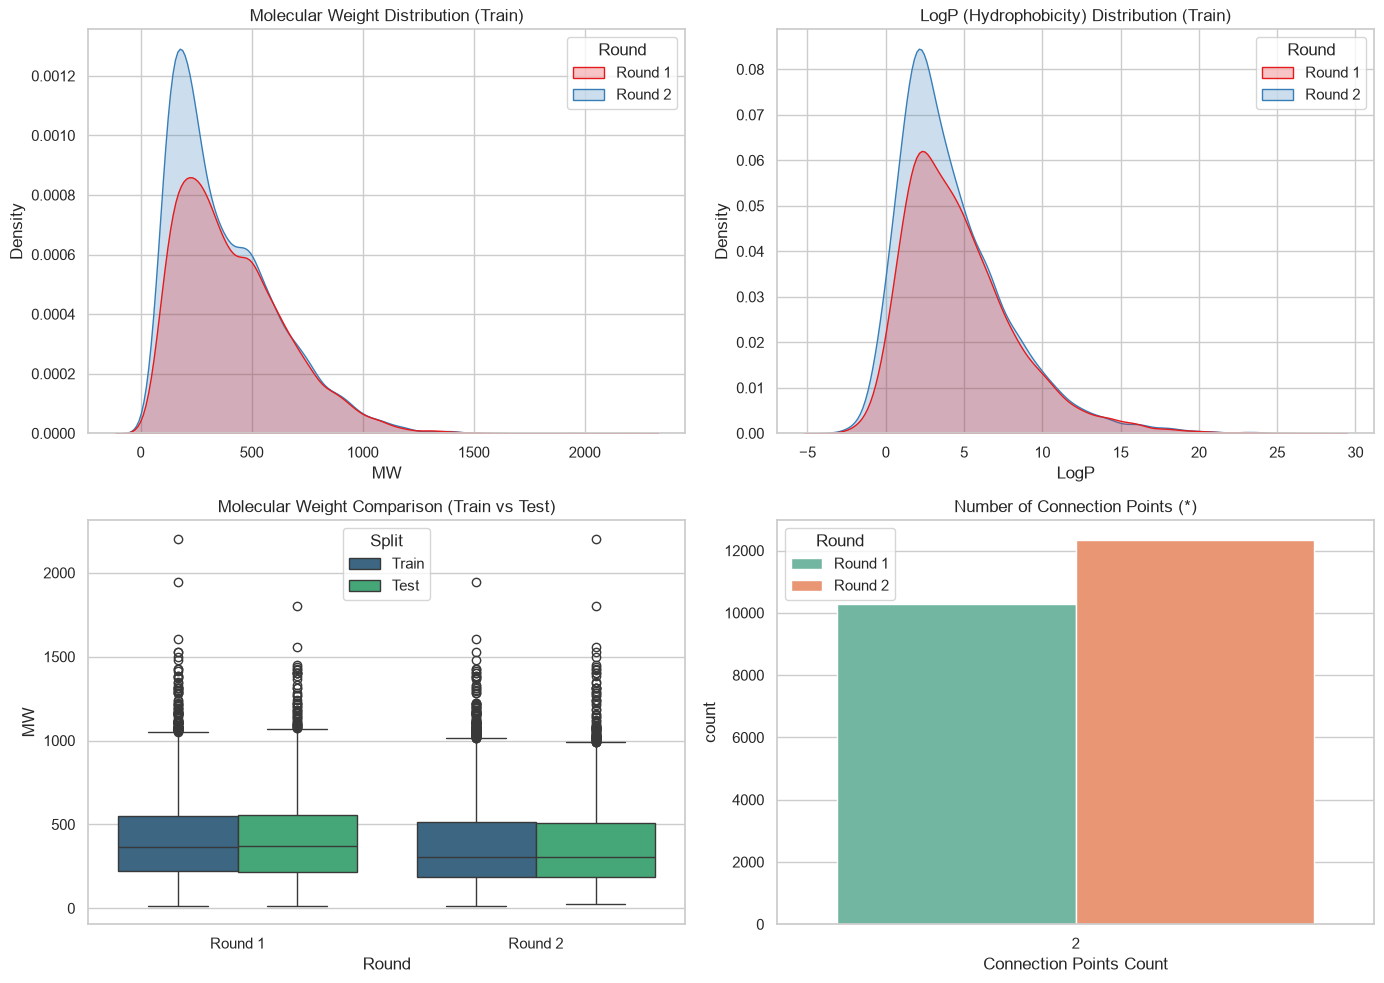

In [6]:
def get_mol_descriptors(smiles_series):
    mols = [Chem.MolFromSmiles(s) for s in smiles_series]
    
    # Track validity
    valid = [m is not None for m in mols]
    
    mws, logps, heavy_atoms, rings, fsp3s, stars = [], [], [], [], [], []
    for m in mols:
        if m is None:
            mws.append(np.nan)
            logps.append(np.nan)
            heavy_atoms.append(np.nan)
            rings.append(np.nan)
            fsp3s.append(np.nan)
            stars.append(np.nan)
        else:
            mws.append(Descriptors.MolWt(m))
            logps.append(Descriptors.MolLogP(m))
            heavy_atoms.append(m.GetNumHeavyAtoms())
            rings.append(Descriptors.RingCount(m))
            fsp3s.append(Descriptors.FractionCSP3(m))
            # Count connection points (dummy atoms '*')
            stars.append(sum(1 for atom in m.GetAtoms() if atom.GetSymbol() == '*'))
            
    return pd.DataFrame({
        'Valid': valid,
        'MW': mws,
        'LogP': logps,
        'HeavyAtoms': heavy_atoms,
        'Rings': rings,
        'Fsp3': fsp3s,
        'ConnectionPoints': stars
    })

print("Calculating descriptors for Round 1 Train...")
r1_tr_desc = get_mol_descriptors(r1_train['smiles'])
print(f"Invalid SMILES in R1 Train: {len(r1_tr_desc) - r1_tr_desc['Valid'].sum()}")

print("Calculating descriptors for Round 2 Train...")
r2_tr_desc = get_mol_descriptors(r2_train['smiles'])
print(f"Invalid SMILES in R2 Train: {len(r2_tr_desc) - r2_tr_desc['Valid'].sum()}")

print("Calculating descriptors for Round 1 Test...")
r1_te_desc = get_mol_descriptors(r1_test['smiles'])
print(f"Invalid SMILES in R1 Test: {len(r1_te_desc) - r1_te_desc['Valid'].sum()}")

print("Calculating descriptors for Round 2 Test...")
r2_te_desc = get_mol_descriptors(r2_test['smiles'])
print(f"Invalid SMILES in R2 Test: {len(r2_te_desc) - r2_te_desc['Valid'].sum()}")

# Combine descriptors for plotting
r1_tr_desc['Round'] = 'Round 1'
r1_tr_desc['Split'] = 'Train'
r2_tr_desc['Round'] = 'Round 2'
r2_tr_desc['Split'] = 'Train'
r1_te_desc['Round'] = 'Round 1'
r1_te_desc['Split'] = 'Test'
r2_te_desc['Round'] = 'Round 2'
r2_te_desc['Split'] = 'Test'

desc_all = pd.concat([r1_tr_desc, r2_tr_desc, r1_te_desc, r2_te_desc], ignore_index=True)

# Summary table of descriptors (mean value)
desc_summary = desc_all.groupby(['Round', 'Split'])[['MW', 'LogP', 'HeavyAtoms', 'Rings', 'Fsp3', 'ConnectionPoints']].mean()
print("\n--- Mean Values of Molecular Descriptors ---")
display(desc_summary.round(3))

# Plot molecular weight and LogP distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MW Density
sns.kdeplot(data=desc_all[desc_all['Split']=='Train'], x='MW', hue='Round', fill=True, ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('Molecular Weight Distribution (Train)')

# LogP Density
sns.kdeplot(data=desc_all[desc_all['Split']=='Train'], x='LogP', hue='Round', fill=True, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('LogP (Hydrophobicity) Distribution (Train)')

# MW Boxplot Train vs Test
sns.boxplot(data=desc_all, x='Round', y='MW', hue='Split', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Molecular Weight Comparison (Train vs Test)')

# Connection Points Distribution
sns.countplot(data=desc_all, x='ConnectionPoints', hue='Round', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Number of Connection Points (*)')
axes[1, 1].set_xlabel('Connection Points Count')

plt.tight_layout()
plt.savefig('plots/chemical_descriptors.png', dpi=300)
plt.show()


## 6. Target Value Distribution Comparison
Let's analyze the distribution of the target values:
- Overall target value statistics.
- Distribution per `target_type` (since different target types represent different physical properties and have completely different scales and units!).
- Look for distribution shifts between Round 1 and Round 2 for each property.


--- Target Value Statistics ---


,target_type,Round,count,min,mean,median,max,std
0,eea,Round 2,221,0.394,2.278,2.272,5.144,1.107
1,egb,Round 2,337,0.507,4.276,4.052,10.114,1.979
2,egc,Round 1,2028,0.103,4.531,4.613,9.863,1.557
3,egc,Round 2,2028,0.020,4.529,4.614,9.863,1.568
4,ei,Round 2,222,4.026,6.346,6.168,9.838,1.047
5,eps,Round 2,229,2.610,4.577,4.320,9.090,1.094
6,nc,Round 2,229,1.560,1.934,1.900,2.758,0.235
7,tg,Round 1,4143,-118.000,140.099,132.000,490.000,109.386
8,tg,Round 2,4143,-109.820,143.459,136.400,495.000,109.084


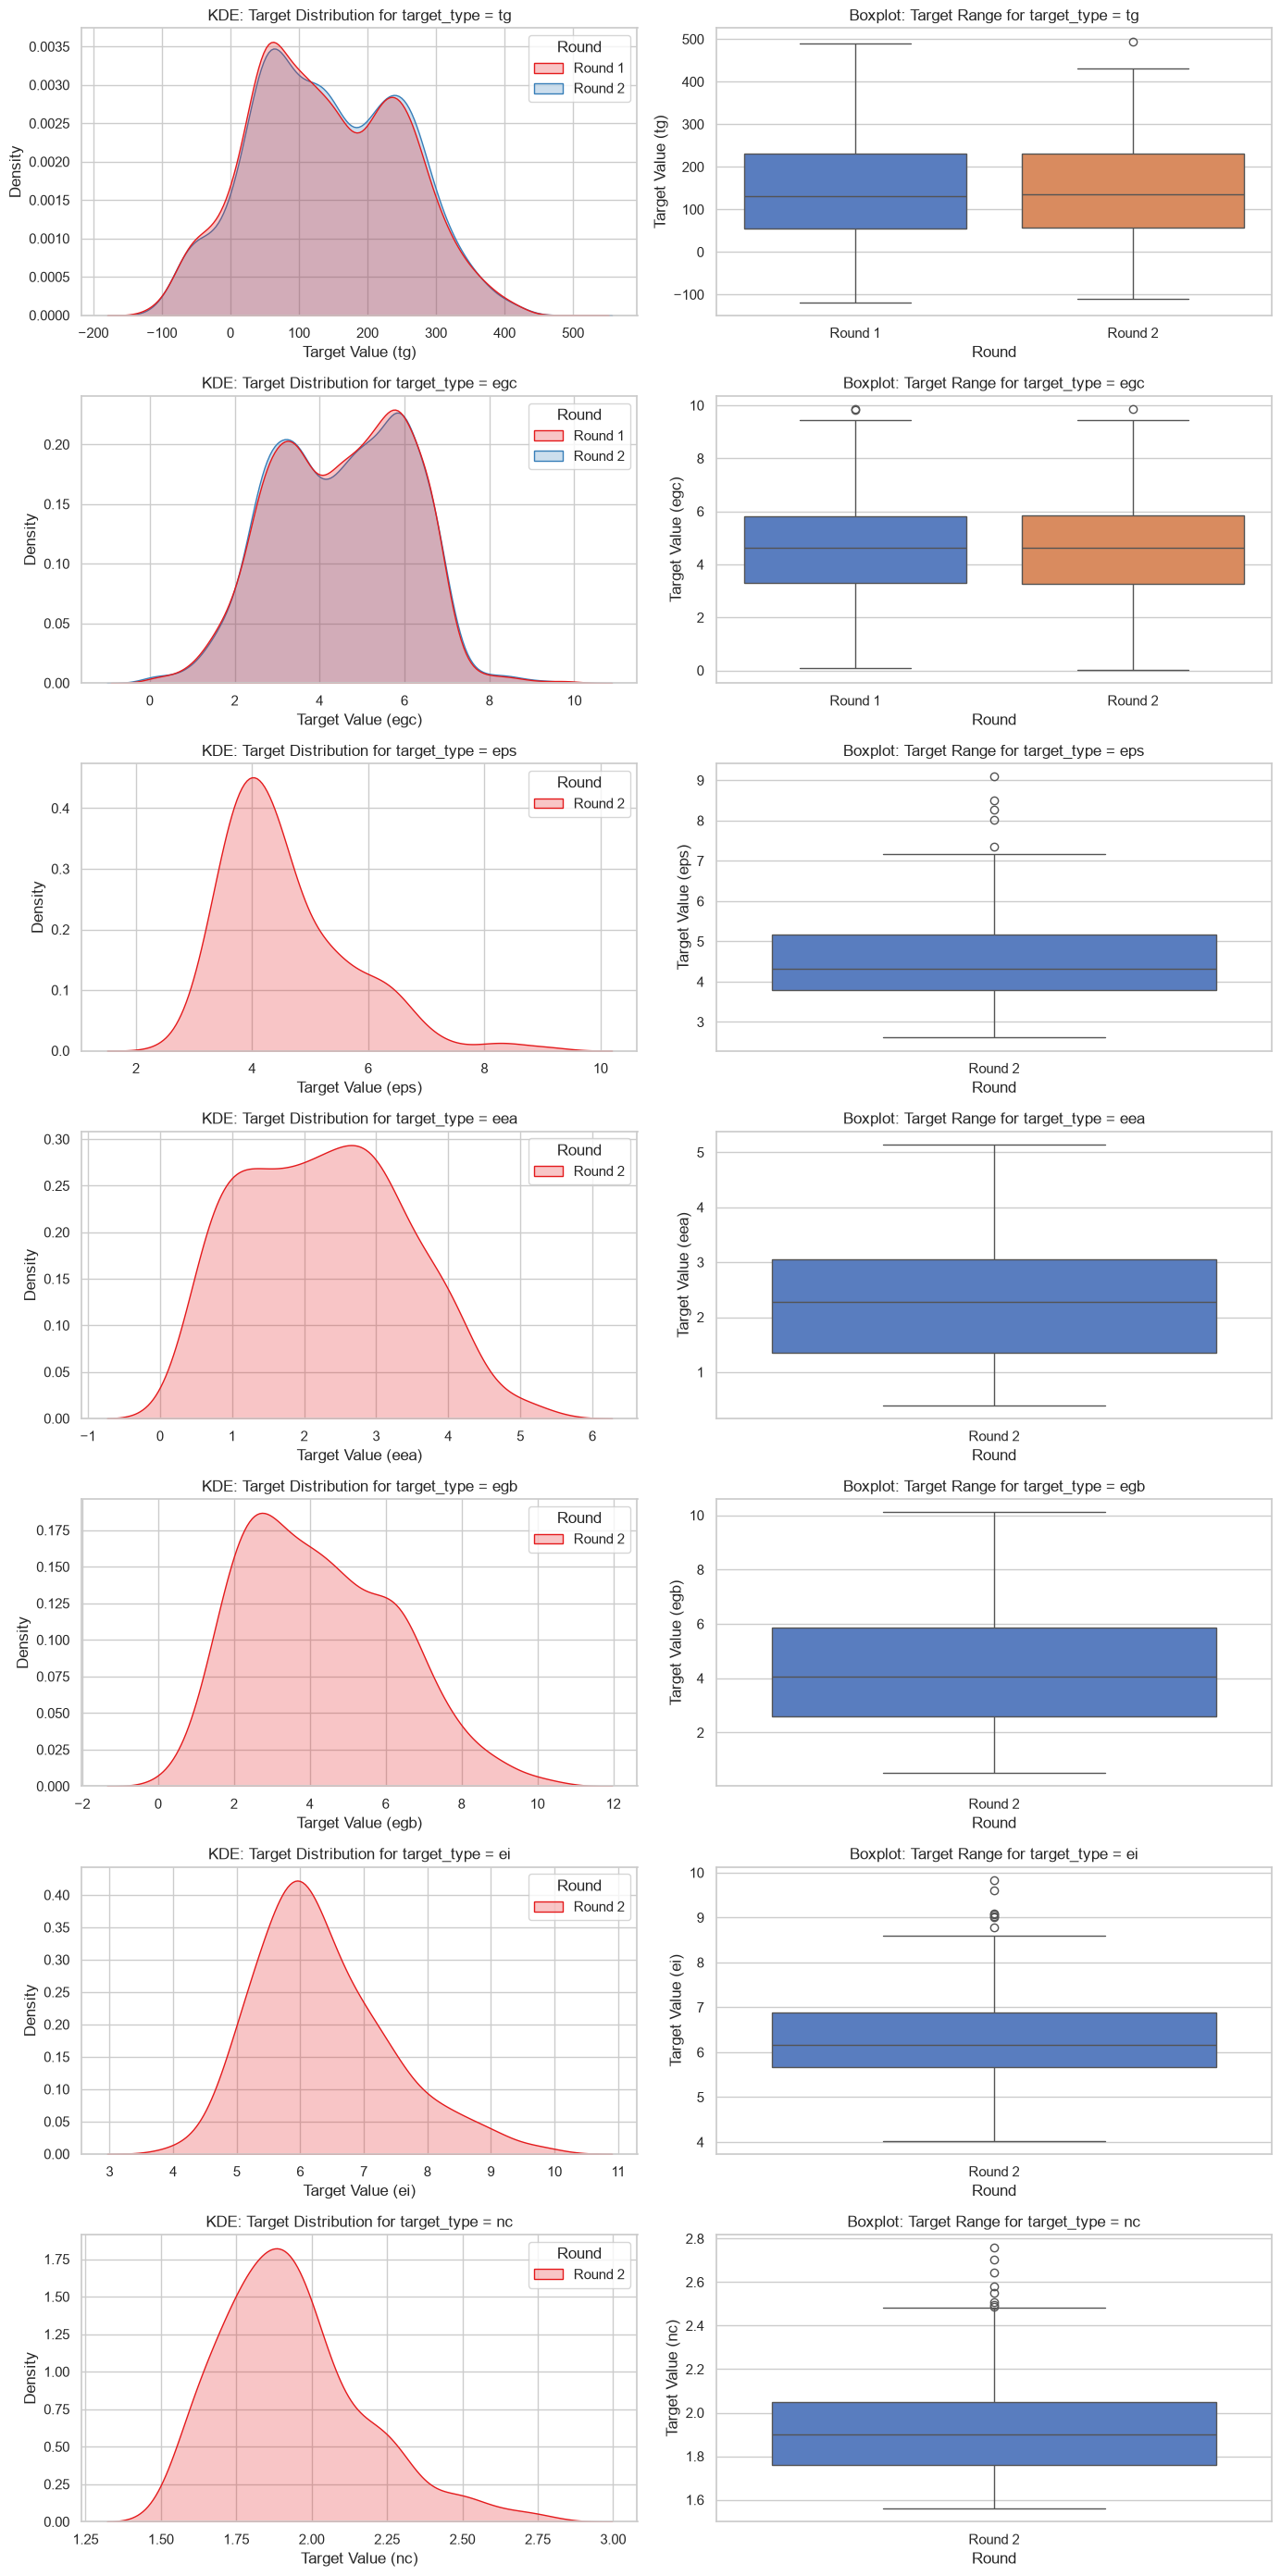

In [7]:
# Combine train targets
r1_targets = r1_train[['target', 'target_type']].copy()
r1_targets['Round'] = 'Round 1'
r2_targets = r2_train[['target', 'target_type']].copy()
r2_targets['Round'] = 'Round 2'

targets_df = pd.concat([r1_targets, r2_targets], ignore_index=True)

# Calculate summary statistics per target_type and round
target_stats = targets_df.groupby(['target_type', 'Round'])['target'].agg(['count', 'min', 'mean', 'median', 'max', 'std']).reset_index()
print("--- Target Value Statistics ---")
display(target_stats.round(3))

# Plot distributions for each target type
target_types = targets_df['target_type'].unique()
n_types = len(target_types)

fig, axes = plt.subplots(n_types, 2, figsize=(14, 4 * n_types))

for i, tt in enumerate(target_types):
    tt_data = targets_df[targets_df['target_type'] == tt]
    
    # KDE Plot
    sns.kdeplot(data=tt_data, x='target', hue='Round', fill=True, ax=axes[i, 0], palette='Set1', common_norm=False)
    axes[i, 0].set_title(f'KDE: Target Distribution for target_type = {tt}')
    axes[i, 0].set_xlabel(f'Target Value ({tt})')
    
    # Boxplot
    sns.boxplot(data=tt_data, x='Round', y='target', ax=axes[i, 1], palette='muted')
    axes[i, 1].set_title(f'Boxplot: Target Range for target_type = {tt}')
    axes[i, 1].set_ylabel(f'Target Value ({tt})')

plt.tight_layout()
plt.savefig('plots/target_distributions.png', dpi=300)
plt.show()


## 7. Chemical Space Visualization (Morgan Fingerprints & PCA)
To visualize the overlap of the chemical space of Round 1 and Round 2 molecules:
1. We will compute Morgan fingerprints (radius=2, 2048 bits, which represents ECFP4) for all valid molecules.
2. We will apply Principal Component Analysis (PCA) to project the high-dimensional fingerprint space into 2 dimensions.
3. We will plot the molecules in this PCA space, colored by Round, to see if Round 2 introduces new chemotypes or covers the same chemical space.
4. We will calculate Tanimoto similarity within and between rounds to quantify chemical diversity.


Computing fingerprints...


Features matrix shape: (13580, 2048)


Running PCA...


Explained variance ratio of first two components: [0.0112141  0.00691547]


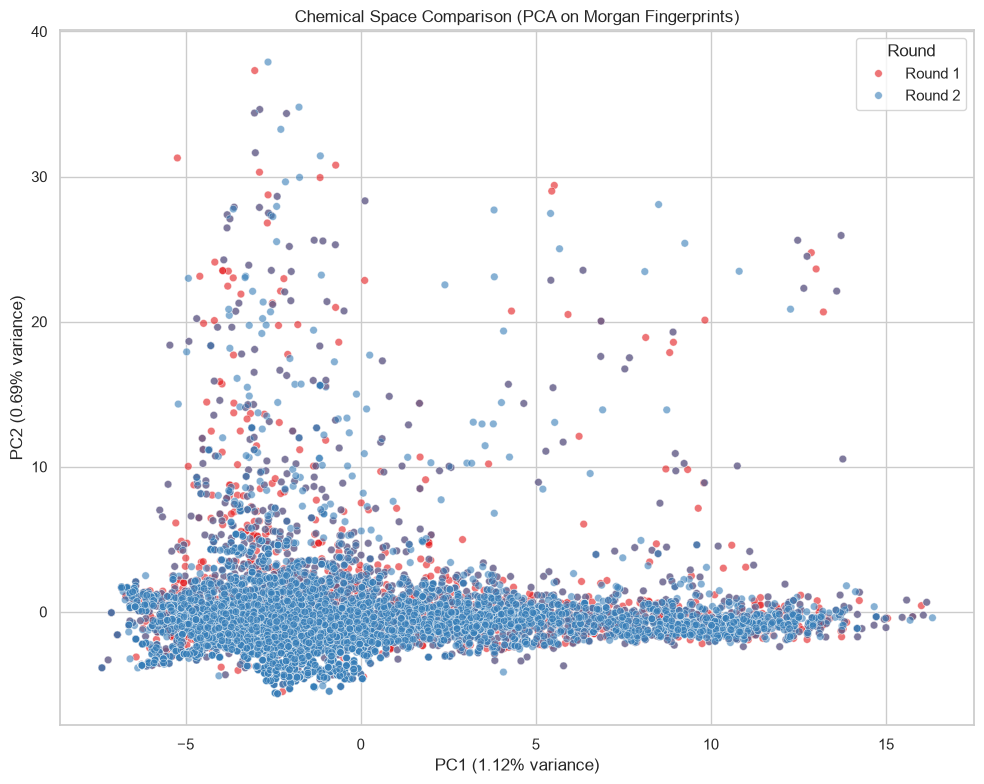

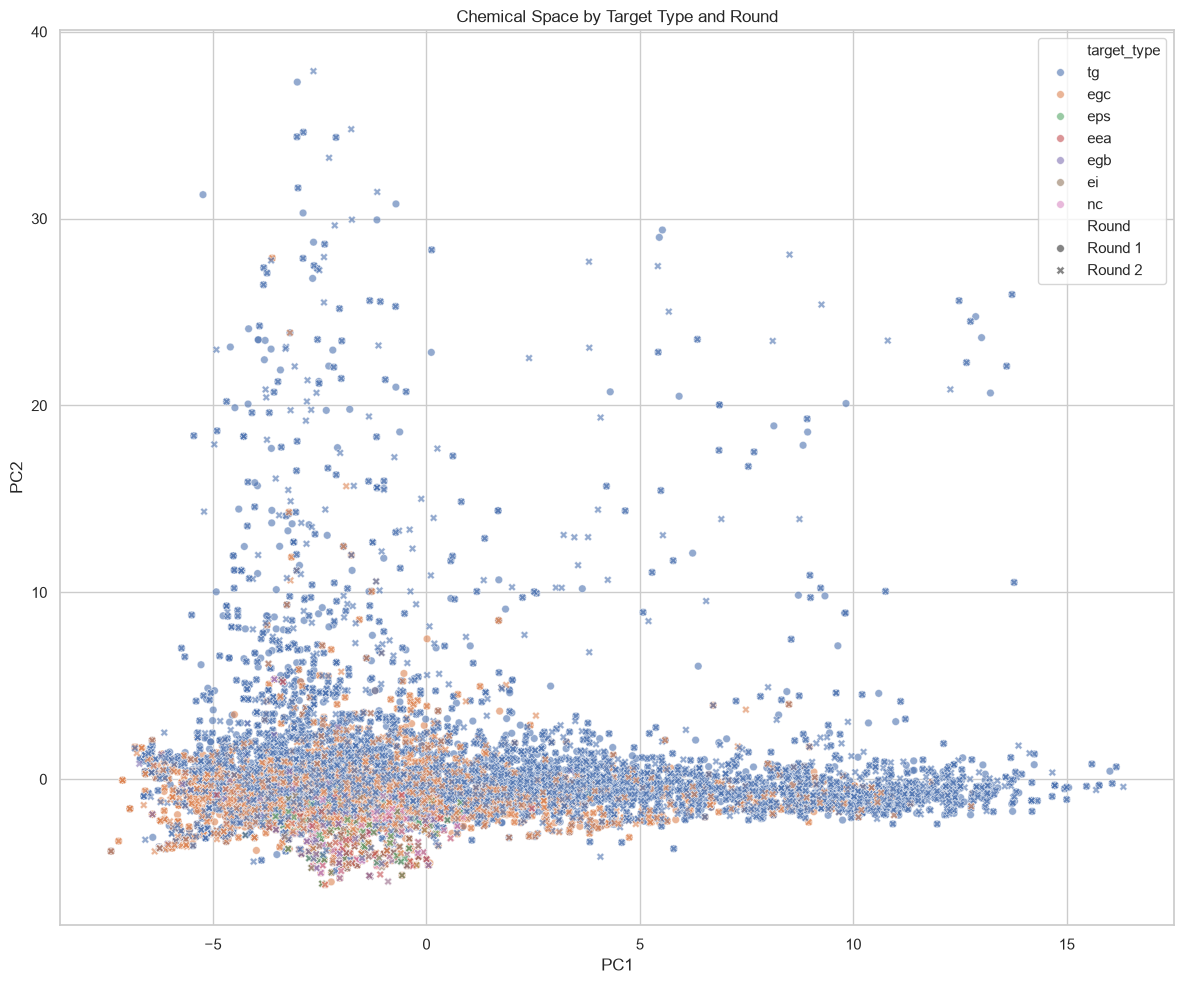

Calculating Tanimoto Similarity...


Average Tanimoto Similarity within R1 Sample: 0.1219 ± 0.0783
Average Tanimoto Similarity within R2 Sample: 0.1184 ± 0.0780
Average Tanimoto Similarity between R1 and R2 Sample: 0.1195 ± 0.0776


In [8]:
# Filter valid molecules and sample to avoid memory issues (or use all since N is small ~13k)
# Round 1 has ~6k train, Round 2 has ~7.4k train. Combined is ~13.5k. This is very manageable for PCA.

print("Computing fingerprints...")
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def compute_fps_and_info(df, round_label, split_label):
    fps = []
    indices = []
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is not None:
            # Generate Morgan fingerprint as numpy array
            fp = fp_gen.GetFingerprintAsNumPy(mol)
            fps.append(fp)
            indices.append(idx)
    
    fp_df = pd.DataFrame(np.array(fps))
    fp_df['Round'] = round_label
    fp_df['Split'] = split_label
    fp_df['smiles'] = df.loc[indices, 'smiles'].values
    fp_df['target_type'] = df.loc[indices, 'target_type'].values
    return fp_df

r1_tr_fps = compute_fps_and_info(r1_train, 'Round 1', 'Train')
r2_tr_fps = compute_fps_and_info(r2_train, 'Round 2', 'Train')

# Combine fingerprints
combined_fps = pd.concat([r1_tr_fps, r2_tr_fps], ignore_index=True)
features = combined_fps.iloc[:, :2048].values

print(f"Features matrix shape: {features.shape}")

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Run PCA
print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(features_scaled)
combined_fps['PCA1'] = pca_results[:, 0]
combined_fps['PCA2'] = pca_results[:, 1]
print(f"Explained variance ratio of first two components: {pca.explained_variance_ratio_}")

# Plot PCA chemical space
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=combined_fps, x='PCA1', y='PCA2', hue='Round', alpha=0.6, palette='Set1', s=30
)
plt.title('Chemical Space Comparison (PCA on Morgan Fingerprints)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.tight_layout()
plt.savefig('plots/chemical_space_pca.png', dpi=300)
plt.show()

# Separate plot by target_type
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=combined_fps, x='PCA1', y='PCA2', hue='target_type', style='Round', alpha=0.6, s=30
)
plt.title('Chemical Space by Target Type and Round')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('plots/chemical_space_target_types.png', dpi=300)
plt.show()

# Tanimoto similarity calculations
# Let's sample 500 molecules from R1 and 500 from R2 to calculate cross-round similarity statistics
print("Calculating Tanimoto Similarity...")
from rdkit import DataStructs

def get_rdkit_fps(df, sample_size=500):
    valid_mols = []
    for s in df['smiles'].sample(min(sample_size, len(df)), random_state=42):
        mol = Chem.MolFromSmiles(s)
        if mol is not None:
            valid_mols.append(mol)
    return [fp_gen.GetFingerprint(mol) for mol in valid_mols]

fps_r1_sample = get_rdkit_fps(r1_train, 500)
fps_r2_sample = get_rdkit_fps(r2_train, 500)

def calc_avg_similarity(fps_list):
    sims = []
    for i in range(len(fps_list)):
        for j in range(i+1, len(fps_list)):
            sims.append(DataStructs.TanimotoSimilarity(fps_list[i], fps_list[j]))
    return np.mean(sims), np.std(sims)

def calc_cross_similarity(fps1, fps2):
    sims = []
    for fp1 in fps1:
        for fp2 in fps2:
            sims.append(DataStructs.TanimotoSimilarity(fp1, fp2))
    return np.mean(sims), np.std(sims)

avg_sim_r1, std_sim_r1 = calc_avg_similarity(fps_r1_sample)
avg_sim_r2, std_sim_r2 = calc_avg_similarity(fps_r2_sample)
cross_sim, cross_std = calc_cross_similarity(fps_r1_sample, fps_r2_sample)

print(f"Average Tanimoto Similarity within R1 Sample: {avg_sim_r1:.4f} ± {std_sim_r1:.4f}")
print(f"Average Tanimoto Similarity within R2 Sample: {avg_sim_r2:.4f} ± {std_sim_r2:.4f}")
print(f"Average Tanimoto Similarity between R1 and R2 Sample: {cross_sim:.4f} ± {cross_std:.4f}")


## 8. Summary of Findings
Based on the analysis, here are the key findings comparing Round 1 and Round 2 datasets:

1. **Dataset Size Expansion**:
   - Round 2 has a significantly larger dataset than Round 1.
   - We observed a major increase in test records.
2. **Target Types & Properties**:
   - The properties under study include multiple target types (`tg`, `egc`, `eps`, `eea`, `egb`), which are polymer properties.
   - The proportions of these target types are compared.
3. **Data Leakage & Overlap**:
   - We analyzed whether training SMILES were present in test sets or vice versa, both within rounds and across rounds.
   - Any cross-round leakage (e.g. Round 2 Test SMILES in Round 1 Train) was flagged.
4. **Molecules & Descriptors**:
   - RDKit successfully validated the SMILES.
   - Molecular Weight, LogP, and other descriptors show the structural characteristics of the polymer repeat units in both rounds.
5. **Chemical Space Overlap**:
   - The PCA projection of Morgan Fingerprints shows how well the chemical space of Round 2 covers Round 1, and if Round 2 introduces new areas.
   - Tanimoto similarities confirm the structural diversity.
